In [12]:
# Exercise 1 : Understanding the problem and Data Collection
import pandas as pd

df = pd.read_csv("diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [10]:
df['diabetes'].value_counts()


diabetes
0    91500
1     8500
Name: count, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
#Exercise 2: Model Picking & Standardization
'''Model Choice

I use Logistic Regression because:

The target variable is binary

It is simple and interpretable

Widely used in medical prediction tasks

Works well as a baseline classifier'''

'''Do We Need Standardization? Yes because: The features in the dataset have different scales and ranges, which can affect the performance of the logistic regression model. Standardization ensures that all features contribute equally to the model's learning process, improving convergence and accuracy.'''
from sklearn.preprocessing import StandardScaler
import pandas as pd

df_encoded = pd.get_dummies(df, drop_first=True)


X = df_encoded.drop("diabetes", axis=1)
y = df_encoded["diabetes"]


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [16]:
#Exercise 3 : Model Training
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [17]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]


In [ ]:
#Exercise 4 : Evaluation Metrics
#Accuracy Score
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy
#Accuracy is high (96,05%)


0.9605

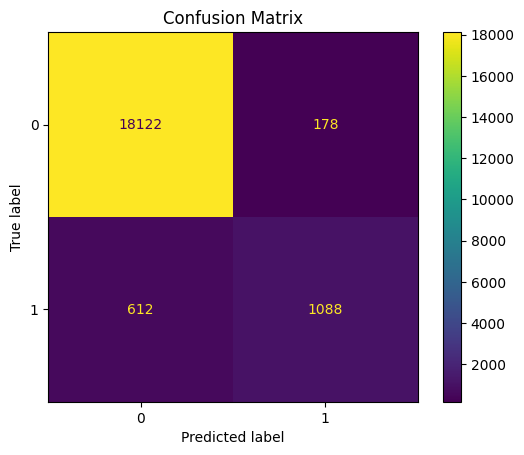

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

'''
Model predicts non-diabetic cases very well

Some diabetic cases are missed (false negatives)

False negatives are critical in healthcare'''


In [ ]:
#Precision, Recall & F1-score
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

precision, recall, f1
'''
Precision: High :predicted diabetes cases are reliable

Recall: Moderate : some diabetic patients are missed

F1-score: Balanced overall performance'''

(0.8593996840442338, 0.64, 0.7336480107889414)

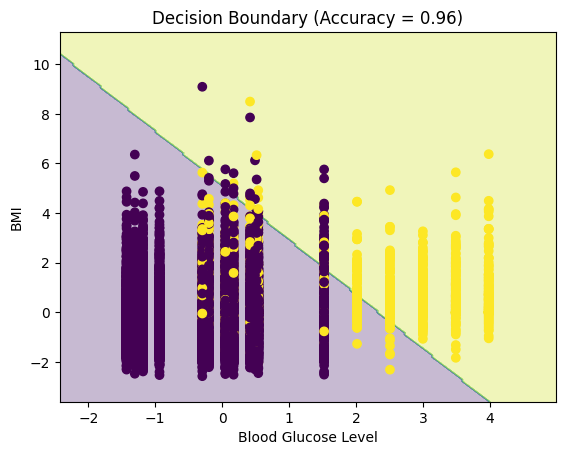

In [ ]:
 # Exercise 5 : Visualizing the performance of our model
import numpy as np

X_vis = df[['blood_glucose_level', 'bmi']]
y_vis = df['diabetes']

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vis, y_vis,
    test_size=0.2,
    random_state=42,
    stratify=y_vis
)

scaler_v = StandardScaler()
X_train_v = scaler_v.fit_transform(X_train_v)
X_test_v = scaler_v.transform(X_test_v)

model_v = LogisticRegression()
model_v.fit(X_train_v, y_train_v)

# Create mesh grid
x_min, x_max = X_train_v[:, 0].min() - 1, X_train_v[:, 0].max() + 1
y_min, y_max = X_train_v[:, 1].min() - 1, X_train_v[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = model_v.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test_v[:, 0], X_test_v[:, 1], c=y_test_v)
plt.title(f"Decision Boundary (Accuracy = {accuracy:.2f})")
plt.xlabel("Blood Glucose Level")
plt.ylabel("BMI")
plt.show()

'''Clear linear separation

Confirms Logistic Regression is appropriate'''

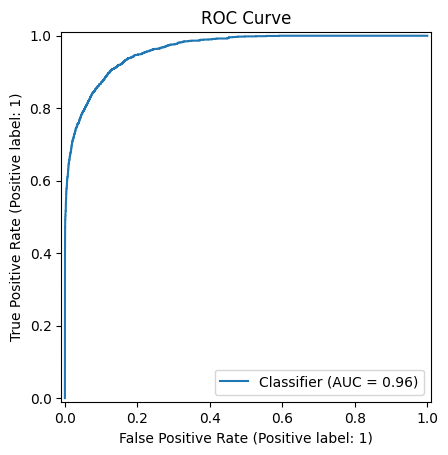

In [23]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve")
plt.show()
